### PE09 - Data Aggregation:

In this exercise, you will work with a dataset containing information about diamonds. You will explore various data aggregation techniques using Pandas, including groupby(), agg(), apply(), transform(), filter(), and pivot_table(). You will also be performing some data visualization that are based on the results of data aggregation.

This exercise is designed to enhance your understanding of these methods by performing tasks such as grouping data, applying custom functions, generating summary statistics, as well as visualizing results for easy interpretation.

#### Step 1: Load the Dataset
1. Start by loading the diamonds dataset into a Pandas DataFrame.

2. Display the first few rows of the dataset to get familiar with its structure.

3. Clean the data and remove unecessary columns (if applicable).

In [3]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/alexgarcia/Desktop/CityUniversity/MSDS/DS522 Data Aquisition and Analytics/Modules/Module9/PE09/diamonds.csv")


df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

#### Step 2: Grouping and Aggregation
1. Group by cut and calculate the following aggregations:
    
    a. The average price for each cut.

    b. The total carat weight for each cut.
    
    c. The maximum depth for each cut.

2. Calculate the median price for diamonds by cut and color and store it in a variable called median_price_by_cut_color.

In [ ]:
df.groupby('cut').agg(
    avg_price=('price', 'mean'),
    total_carat=('carat', 'sum'),
    max_depth=('depth', 'max')
)

,avg_price,total_carat,max_depth
cut,,,
Fair,4358.757764,1684.28,79.0
Good,3928.864452,4166.10,67.0
Ideal,3457.541970,15146.84,66.7
Premium,4584.257704,12300.95,63.0
Very Good,3981.759891,9742.70,64.9


In [ ]:
median_price_by_cut_color = df.groupby(['cut', 'color'])['price'].median()
median_price_by_cut_color

cut        color
Fair       D        3730.0
           E        2956.0
           F        3035.0
           G        3057.0
           H        3816.0
           I        3246.0
           J        3302.0
Good       D        2728.5
           E        2420.0
           F        2647.0
           G        3340.0
           H        3468.5
           I        3639.5
           J        3733.0
Ideal      D        1576.0
           E        1437.0
           F        1775.0
           G        1857.5
           H        2278.0
           I        2659.0
           J        4096.0
Premium    D        2009.0
           E        1928.0
           F        2841.0
           G        2745.0
           H        4511.0
           I        4640.0
           J        5063.0
Very Good  D        2310.0
           E        1989.5
           F        2471.0
           G        2437.0
           H        3734.0
           I        3888.0
           J        4113.0
Name: price, dtype: float64

#### Step 3: Applying Custom Functions
1. Define a custom function to calculate the price-to-carat ratio and apply it to each row using apply().
Make sure the output is added to the dataframe.

2. Group by color and apply a custom function using apply() to get the top 3 highest price-to-carat ratio diamonds for each color.

3. Aggregate the data by calculating the mean price_to_carat_ratio for each color. Make sure to reset the index of the top 3 diamonds result before performing the groupby operation.

In [7]:
def price_to_carat_ratio(row):
    return row['price'] / row['carat']

df['price_to_carat_ratio'] = df.apply(price_to_carat_ratio, axis=1)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,price_to_carat_ratio
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,1417.391304
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,1552.380952
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,1421.739130
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,1151.724138
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,1080.645161


In [8]:
top3_by_color = df.groupby('color').apply(
    lambda x: x.nlargest(3, 'price_to_carat_ratio')
)
top3_by_color

/var/folders/mz/8qkq4jfs2j95ts6nw3614pdm0000gn/T/ipykernel_44038/3041360664.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3_by_color = df.groupby('color').apply(


carat        cut color clarity  depth  table  price     x     y  \
color                                                                          
D     27635   1.04  Very Good     D      IF   61.3   56.0  18542  6.53  6.55   
      27530   1.07    Premium     D      IF   60.9   58.0  18279  6.67  6.57   
      27226   1.03      Ideal     D      IF   62.0   56.0  17590  6.55  6.44   
E     27677   1.28      Ideal     E      IF   60.7   57.0  18700  7.09  6.99   
      27139   1.21      Ideal     E      IF   61.8   56.0  17353  6.81  6.88   
      25986   1.09      Ideal     E      IF   60.1   58.0  15193  6.68  6.72   
F     27591   1.33      Ideal     F      IF   60.2   57.0  18435  7.12  7.17   
      27671   1.42      Ideal     F    VVS1   60.8   56.0  18682  7.25  7.32   
      26166   1.21      Ideal     F      IF   62.8   56.0  15497  6.75  6.84   
G     27673   1.50  Very Good     G     VS2   60.7   59.0  18691  7.31  7.38   
      27747   1.51      Ideal     G      IF   61.7   55.0  18806  7.37  7.41   
      27536   1.54      Ideal     G    VVS1   61.4   56.0  18294  7.42  7.47   
H     26585   1.60      Ideal     H      IF   61.5   53.0  16300  7.57  7.69   
      26557   1.70      Ideal     H     VS1   61.5   55.0  16240  7.69  7.73   
      25511   1.50      Ideal     H    VVS1   61.2   57.0  14304  7.34  7.40   
I     27743   2.00    Premium     I     VS1   60.8   59.0  18795  8.13  8.02   
      27617   2.01  Very Good     I     VS1   63.0   59.0  18500  7.87  7.94   
      27734   2.06      Ideal     I     VS2   62.2   55.0  18779  8.15  8.19   
J     27400   2.08      Ideal     J      IF   61.0   55.0  17986  8.32  8.25   
      27602   2.16      Ideal     J     VS1   61.4   55.0  18462  8.34  8.27   
      27129   2.04      Ideal     J      IF   61.5   58.0  17327  8.11  8.14   

                z  price_to_carat_ratio  
color                                    
D     27635  4.01          17828.846154  
      27530  4.03          17083.177570  
      27226  4.03          17077.669903  
E     27677  4.27          14609.375000  
      27139  4.23          14341.322314  
      25986  4.03          13938.532110  
F     27591  4.30          13860.902256  
      27671  4.43          13156.338028  
      26166  4.27          12807.438017  
G     27673  4.46          12460.666667  
      27747  4.56          12454.304636  
      27536  4.57          11879.220779  
H     26585  4.66          10187.500000  
      26557  4.74           9552.941176  
      25511  4.51           9536.000000  
I     27743  4.91           9397.500000  
      27617  4.98           9203.980100  
      27734  5.08           9116.019417  
J     27400  5.05           8647.115385  
      27602  5.10           8547.222222  
      27129  5.00           8493.627451

In [9]:
top3_reset = top3_by_color.reset_index(drop=True)
mean_ratio_by_color = top3_reset.groupby('color')['price_to_carat_ratio'].mean()
mean_ratio_by_color

color
D    17329.897876
E    14296.409808
F    13274.892767
G    12264.730694
H     9758.813725
I     9239.166506
J     8562.655019
Name: price_to_carat_ratio, dtype: float64

#### Step 4: Transforming Data
1. Standardize the price column within each cut group using transform().

Formula: standardized_price = (price - mean) / standard deviation

2. Normalize the price column within each cut group using transform().

Formula: normalized_price = (price - min) / (max - min)

3. Filter out diamonds that are below the 25th percentile in terms of carat weight within each cut group.

Hint: use quantile()

QUESTION: What id the difference between Normalization and Standardization? When is it appropriate to use one from the other?

Normalization rescales values to a [0, 1] range, best used when the data 
distribution is unknown or not Gaussian, and when algorithms are distance-based 
(e.g. KNN, neural networks).

Standardization rescales data to have mean=0 and std=1, best used when the 
data follows a roughly Gaussian distribution and when algorithms assume 
normally distributed data (e.g. linear regression, PCA).

In [10]:
df['standardized_price'] = df.groupby('cut')['price'].transform(
    lambda x: (x - x.mean()) / x.std()
)
df[['cut', 'price', 'standardized_price']].head()

,cut,price,standardized_price
0,Ideal,326,-0.822272
1,Premium,326,-0.979089
2,Good,327,-0.978345
3,Premium,334,-0.977249
4,Good,335,-0.976172


In [11]:
df['normalized_price'] = df.groupby('cut')['price'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
df[['cut', 'price', 'normalized_price']].head()

,cut,price,normalized_price
0,Ideal,326,0.000000
1,Premium,326,0.000000
2,Good,327,0.000000
3,Premium,334,0.000433
4,Good,335,0.000433


In [18]:
df_filtered = df[
    df['carat'] >= df.groupby('cut')['carat'].transform(lambda x: x.quantile(0.25))
]
df_filtered.shape

(41033, 13)

### Step 5: Filtering Data
1. Filter the data to only include color groups where the standard deviation of the price is greater than 1000.

In [13]:
df_std_filtered = df.groupby('color').filter(lambda x: x['price'].std() > 1000)
df_std_filtered.groupby('color')['price'].std()

color
D    3356.590935
E    3344.158685
F    3784.992007
G    4051.102846
H    4215.944171
I    4722.387604
J    4438.187251
Name: price, dtype: float64

### Step 6: Pivot Table
Create a pivot table to summarize the average price of diamonds across different combinations of cut and clarity. Use fill_value=0 for any missing data.

In [14]:
pivot = pd.pivot_table(
    df,
    index='cut',
    columns='clarity',
    values='price',
    aggfunc='mean',
    fill_value=0
)
pivot

clarity,I1,IF,SI1,SI2,VS1,VS2,VVS1,VVS2
cut,,,,,,,,
Fair,3703.533333,1912.333333,4208.279412,5173.916309,4165.141176,4174.724138,3871.352941,3349.768116
Good,3596.635417,4098.323944,3689.533333,4580.260870,3801.445988,4262.236196,2254.774194,3079.108392
Ideal,4335.726027,2272.913366,3752.118169,4755.952656,3489.744497,3284.550385,2468.129458,3250.290100
Premium,3947.331707,3856.143478,4455.269371,5545.936928,4485.462041,4550.331248,2831.206169,3795.122989
Very Good,4078.226190,4396.216418,3932.391049,4988.688095,3805.353239,4215.759552,2459.441065,3037.765182


#### Step 9: Data Visualization
1. Visualize the result of the mean price_to_carat_ratio for each color in Step 3.3 by using a bar plot.

2. Compare the original price, standardize price, and normalized price using histograms. Describe each of their distribution.

3. Visualizing the results of the pivot table using a heatmap.

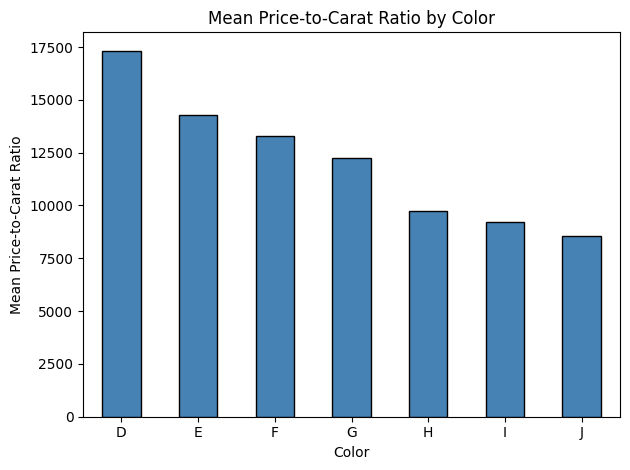

In [15]:
mean_ratio_by_color.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Mean Price-to-Carat Ratio by Color')
plt.xlabel('Color')
plt.ylabel('Mean Price-to-Carat Ratio')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

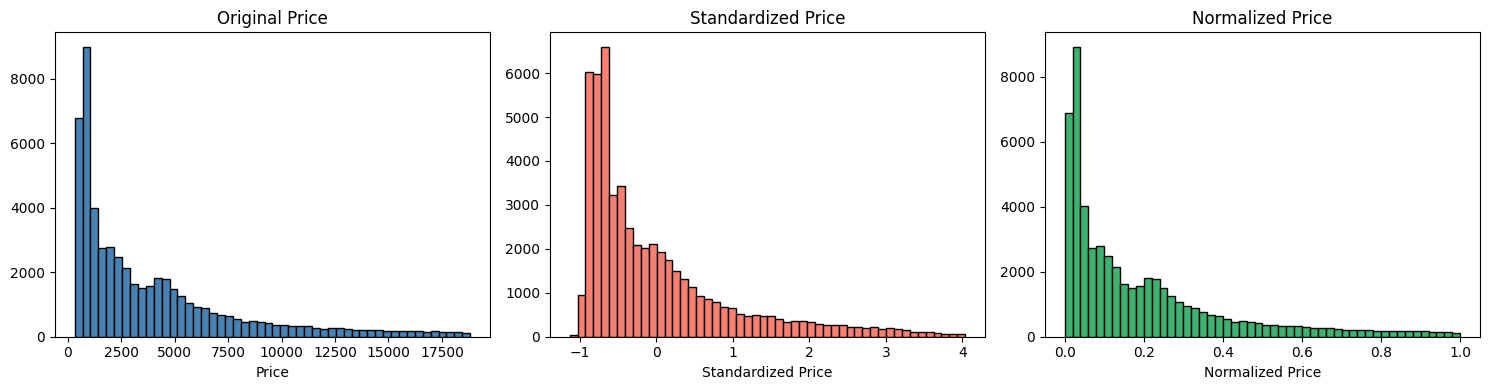

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Original Price')
axes[0].set_xlabel('Price')

axes[1].hist(df['standardized_price'], bins=50, color='salmon', edgecolor='black')
axes[1].set_title('Standardized Price')
axes[1].set_xlabel('Standardized Price')

axes[2].hist(df['normalized_price'], bins=50, color='mediumseagreen', edgecolor='black')
axes[2].set_title('Normalized Price')
axes[2].set_xlabel('Normalized Price')

plt.tight_layout()
plt.show()

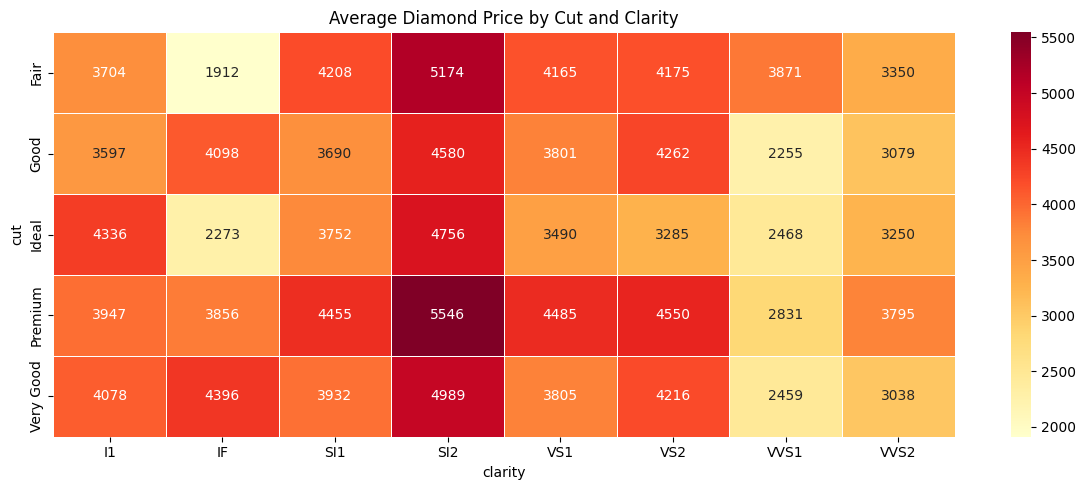

In [17]:
plt.figure(figsize=(12, 5))
sb.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Average Diamond Price by Cut and Clarity')
plt.tight_layout()
plt.show()